## 2.2.1 텐서 다루기
### 텐서 생성 및 변환

In [4]:
# 환경 확인: 파이토치 버전과 GPU 사용 가능 여부
import torch

print(torch.__version__)
print(torch.cuda.is_available())   # 코랩에서 런타임 유형을 GPU로 바꾸면 True

2.11.0+cpu
False


In [5]:
import torch
# 텐서 생성 3가지 방식
print(torch.tensor([[1, 2], [3, 4]]))  # 2차원 형태의 텐서 생성
#print(torch.tensor([[1, 2], [3, 4]], device="cuda:0"))  # GPU에 텐서 생성
print(torch.tensor([[1, 2], [3, 4]], dtype=torch.float64))   # dtype을 지정하여 생성

tensor([[1, 2],
        [3, 4]])
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [6]:
# 1차원 벡터 생성 후 인덱스로 접근
temp = torch.FloatTensor([1, 2, 3, 4, 5, 6, 7])

print(temp[0], temp[1], temp[-1])   # -1은 맨 뒤에서부터 세는 인덱스
print('------------------------')
print(temp[2:5], temp[4:-1])        # 슬라이스: 끝 번호는 포함되지 않음

tensor(1.) tensor(2.) tensor(7.)
------------------------
tensor([3., 4., 5.]) tensor([5., 6.])


### 텐서 연산
타입이 다르면 연산이 불가능하다. (예: FloatTensor + DoubleTensor → 오류)

In [7]:
# 길이가 같은 벡터 간 원소별 뺄셈
v = torch.tensor([1, 2, 3])
w = torch.tensor([3, 4, 6])

print(w - v)

tensor([2, 2, 3])


###텐서 차원 조작
view: 형태 변경 (넘파이 reshape과 유사) / stack: 결합 / cat: 병합 / t, transpose: 차원 교환
-1은 "나머지 차원 보고 알아서 계산"이라는 뜻. 원소 개수 (2x2=4)는 항상 유지된다.

In [8]:
#view로 차원 바꾸기
temp=torch.tensor([[1,2], [3,4]])
print(temp.shape)
print('------------------------')
print(temp.view(4, 1))      # 2×2 → 4×1
print('------------------------')
print(temp.view(-1))        # 1차원 벡터로 펴기
print('------------------------')
print(temp.view(1, -1))     # (1, ?) → 원소 4개 유지해야 하므로 (1, 4)
print('------------------------')
print(temp.view(-1, 1))     # (?, 1) → 원소 4개 유지해야 하므로 (4, 1)

torch.Size([2, 2])
------------------------
tensor([[1],
        [2],
        [3],
        [4]])
------------------------
tensor([1, 2, 3, 4])
------------------------
tensor([[1, 2, 3, 4]])
------------------------
tensor([[1],
        [2],
        [3],
        [4]])


## 2.2.2 데이터 준비
데이터 호출 방법: ① 판다스로 직접 불러오기 ② 커스텀 데이터셋 ③ 파이토치 제공 데이터셋
2.2절 코드는 사용 방법에 대한 예시. 아래 ①②는 csv 파일이 없으면 실행되지 않는다.

In [9]:
### ① 단순하게 파일을 불러와서 사용 (실행 예시 — class2.csv 필요)

#python
#import pandas as pd
#import torch

#data = pd.read_csv('../class2.csv')   # csv 파일을 불러옴

# .values: 판다스 칼럼 → 넘파이 배열
# from_numpy: 넘파이 배열 → 텐서
# unsqueeze(dim=1): 차원 추가 (N,) → (N, 1)
# .float(): 자료형을 float으로
#x = torch.from_numpy(data['x'].values).unsqueeze(dim=1).float()
#y = torch.from_numpy(data['y'].values).unsqueeze(dim=1).float()

In [10]:
### ② 커스텀 데이터셋을 만들어서 사용 (실행 예시 — covtype.csv 필요)

#대량 데이터를 한 번에 메모리에 올리면 비효율적이므로, 조금씩 나누어 불러오는 방식.
#Dataset 상속 후 메서드 3개를 구현한다.

#python
#import pandas as pd
#import torch
#from torch.utils.data import Dataset
#from torch.utils.data import DataLoader

#class CustomDataset(Dataset):
 #   def __init__(self, csv_file):        # 변수 선언 + 데이터셋 전처리
  #      self.label = pd.read_csv(csv_file)

   # def __len__(self):                   # 전체 데이터셋의 크기(총 샘플 수) 반환
    #    return len(self.label)

    #def __getitem__(self, idx):          # idx번째 데이터 하나를 반환 (반환값은 텐서여야 함)
        #sample = torch.tensor(self.label.iloc[idx, 0:3]).int()
        #label  = torch.tensor(self.label.iloc[idx, 3]).int()
        #return sample, label

#tensor_dataset = CustomDataset('../covtype.csv')
#dataset = DataLoader(tensor_dataset, batch_size=4, shuffle=True)

# DataLoader는 데이터를 미리 잘라두지 않고,
# 내부 반복자(iterator)의 인덱스로 배치 크기만큼 그때그때 반환한다.
#for i, data in enumerate(dataset, 0):
    #print(i, end='')
    #batch = data[0]
    #print(batch.size())

### ③ 파이토치에서 제공하는 데이터셋 사용
torchvision: MNIST, ImageNet 등 유명 데이터셋이 모여 있는 패키지.
아래는 코랩에서 실제로 실행 가능하다.

In [11]:
import torchvision.transforms as transforms

# Compose: 여러 전처리를 순서대로 묶음
mnist_transform = transforms.Compose([
    transforms.ToTensor(),                    # 이미지 → 텐서
    transforms.Normalize((0.5,), (1.0,))      # 평균 0.5, 표준편차 1.0이 되도록 분포 조정
])

In [12]:
from torchvision.datasets import MNIST
import requests

download_root = '../chap02/data/MNIST_DATASET'   # 내려받을 경로 지정

train_dataset = MNIST(download_root, transform=mnist_transform, train=True,  download=True)   # 훈련(training) 데이터셋
valid_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)   # 검증(validation) 데이터셋
test_dataset  = MNIST(download_root, transform=mnist_transform, train=False, download=True)   # 테스트(test) 데이터셋

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 351kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.18MB/s]


## 2.2.3 모델 정의 – 단순 신경망

In [13]:
import torch.nn as nn

# nn.Module 상속 없이 계층 하나가 곧 모델
model = nn.Linear(in_features=1, out_features=1, bias=True)
model

Linear(in_features=1, out_features=1, bias=True)

## 2.2.3 모델 정의 – nn.Module 상속

In [14]:
from torch.nn import Module, Linear, Sigmoid
class MLP(Module):
  def __init__(self, inputs):
        super(MLP, self).__init__()          # 부모(Module) 설정 먼저 켜기 – 필수
        self.layer = Linear(inputs, 1)       # 계층 정의
        self.activation = Sigmoid()          # 활성화 함수 정의

  def forward(self, X):                    # 연산 순서: 계층 → 활성화
        X = self.layer(X)
        X = self.activation(X)
        return X
model = MLP (inputs=3)
model


MLP(
  (layer): Linear(in_features=3, out_features=1, bias=True)
  (activation): Sigmoid()
)

## 2.2.3 모델 정의 – nn.Sequential

In [15]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layer1 = nn.Sequential(          # 계층 3개를 묶음 하나로 → forward에서 한 줄로 호출
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2))

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=30, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2))

        self.layer3 = nn.Sequential(
            nn.Linear(in_features=30*5*5, out_features=10, bias=True),   # 30채널×5×5 = 750
            nn.ReLU(inplace=True))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x

model = MLP()                                 # 모델에 대한 객체 생성

print("Printing children\n------------------------------")
print(list(model.children()))                 # 바로 아래 자식 3개(Sequential)만
print("\n\nPrinting Modules\n------------------------------")
print(list(model.modules()))                  # MLP 자신 + 모든 하위 노드 전부

Printing children
------------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
------------------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Linea

## 2.2.3 모델 정의 – 함수로 정의

In [16]:
def MLP(in_features=1, hidden_features=20, out_features=1):
    hidden = nn.Linear(in_features=in_features, out_features=hidden_features,
                       bias=True)                   # 계층을 변수에 저장
    activation = nn.ReLU()
    output = nn.Linear(in_features=hidden_features, out_features=out_features,
                       bias=True)
    net = nn.Sequential(hidden, activation, output)  # 순서대로 묶기
    return net                                        # forward 없음 – Sequential이 순서 담당

model = MLP()
model

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=1, bias=True)
)

## 2.2.4 모델의 파라미터 정의

교재 예시 코드
(`from torch.optim import optimizer`는 존재하지 않는 이름이라 ImportError, `dataloader`·`loss_fn`도 미정의)

from torch.optim import optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer=optimizer,
                                        lr_lambda=lambda epoch: 0.95 ** epoch)
for epoch in range(1, 100+1):        # 에포크 수만큼 데이터를 반복하여 처리
    for x, y in dataloader:          # 배치 크기만큼 데이터를 가져와서 학습 진행
        optimizer.zero_grad()        # 기울기 0으로 초기화
loss_fn(model(x), y).backward()      # 손실 계산 → 기울기 계산
optimizer.step()                     # 파라미터 업데이트
scheduler.step()                     # 학습률 갱신
```

- criterion: 채점 기준 (MSE = 회귀용)
- optimizer: model.parameters()를 넘겨줘야 어떤 w, b를 고칠지 앎
- scheduler: 0.95 ** epoch → 에포크 1일 때 0.95배, 2일 때 0.9025배 … 점점 작아짐

## 2.2.5 모델 훈련

교재 예시 코드 – `x_train`, `y_train`, `criterion`, `optimizer`가 정의되어 있지 않아 실행 불가, 텍스트 셀에 기록

```python
for epoch in range(100):
    yhat = model(x_train)                 # 전방향: 입력 → 출력
    loss = criterion(yhat, y_train)       # 오차 계산
    optimizer.zero_grad()                 # 오차가 중첩적으로 쌓이지 않도록 초기화
    loss.backward()                       # 역전파: 기울기 계산
    optimizer.step()                      # 기울기 업데이트
```

## 2.2.6 모델 평가 – 함수 이용

In [17]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 28.7 MB/s eta 0:00:00


In [18]:
import torch
import torchmetrics
metric = torchmetrics.Accuracy(task="multiclass", num_classes=5)   # 모델 평가(정확도) 초기화

n_batches = 10
for i in range(n_batches):
    preds = torch.randn(10, 5).softmax(dim=-1)
    target = torch.randint(5, (10,))

    acc = metric(preds, target)              # 이번 배치 정확도 (내부에 누적됨)
    print(f"Accuracy on batch {i}: {acc}")   # 현재 배치에서 모델 평가(정확도)

acc = metric.compute()                       # 누적된 전체 정확도
print(f"Accuracy on all data: {acc}")        # 모든 배치에서 모델 평가(정확도)

Accuracy on batch 0: 0.5
Accuracy on batch 1: 0.5
Accuracy on batch 2: 0.20000000298023224
Accuracy on batch 3: 0.0
Accuracy on batch 4: 0.10000000149011612
Accuracy on batch 5: 0.10000000149011612
Accuracy on batch 6: 0.30000001192092896
Accuracy on batch 7: 0.20000000298023224
Accuracy on batch 8: 0.20000000298023224
Accuracy on batch 9: 0.10000000149011612
Accuracy on all data: 0.2199999988079071


## 2.2.6 모델 평가 – 모듈 이용

In [19]:
import torch
import torchmetrics
metric = torchmetrics.Accuracy(task="multiclass", num_classes=5)   # 모델 평가(정확도) 초기화

n_batches = 10
for i in range(n_batches):
    preds = torch.randn(10, 5).softmax(dim=-1)
    target = torch.randint(5, (10,))

    acc = metric(preds, target)              # 이번 배치 정확도 (내부에 누적됨)
    print(f"Accuracy on batch {i}: {acc}")   # 현재 배치에서 모델 평가(정확도)

acc = metric.compute()                       # 누적된 전체 정확도
print(f"Accuracy on all data: {acc}")        # 모든 배치에서 모델 평가(정확도)

Accuracy on batch 0: 0.4000000059604645
Accuracy on batch 1: 0.10000000149011612
Accuracy on batch 2: 0.0
Accuracy on batch 3: 0.4000000059604645
Accuracy on batch 4: 0.5
Accuracy on batch 5: 0.30000001192092896
Accuracy on batch 6: 0.4000000059604645
Accuracy on batch 7: 0.20000000298023224
Accuracy on batch 8: 0.0
Accuracy on batch 9: 0.20000000298023224
Accuracy on all data: 0.25


In [20]:
import torch, sys
print(sys.version)        # 파이썬 버전
print(torch.__version__)  # 파이토치 버전

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
2.11.0+cpu


In [21]:
# ★ 교재에 없음 — 업로드 대신 깃허브에서 직접 다운로드
import os
os.makedirs('../chap02/data', exist_ok=True)
!wget -q -O ../chap02/data/car_evaluation.csv https://raw.githubusercontent.com/gilbutITbook/080289/main/chap02/data/car_evaluation.csv
print(os.listdir('../chap02/data'))

['MNIST_DATASET', 'car_evaluation.csv']


In [22]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns
%matplotlib inline

## 코드 2-2 데이터 호출
- `pd.read_csv()`: csv → DataFrame
- `head()`: 처음 5줄(기본값). `tail()`은 마지막 5줄. 인덱스는 0부터.

In [23]:
dataset = pd.read_csv('../chap02/data/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 코드 2-3 예제 데이터셋 분포
출력 결과가 단어(vhigh, small…)와 숫자로 되어 있음 → 컴퓨터는 단어를 못 읽으니 **임베딩** 처리 필요.

<Axes: ylabel='count'>

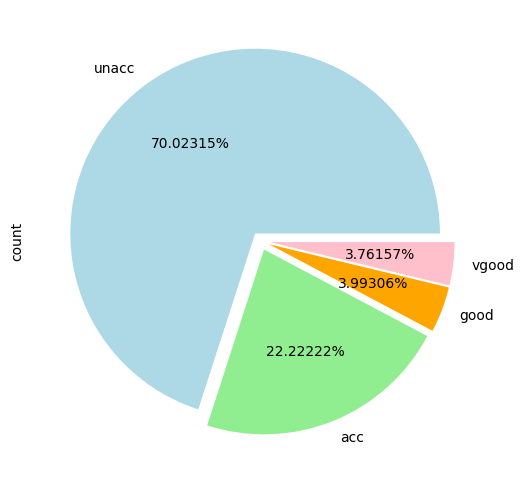

In [24]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

## 코드 2-4 데이터를 범주형 타입으로 변환
절차: **범주형 데이터 → dataset[category] → 넘파이 배열 → 텐서**
- `astype('category')`: 범주형 타입으로 변환
- `cat.codes`: 단어 → 숫자. ⚠️ 어떤 클래스가 어떤 숫자에 매핑됐는지 확인 어려움
- `np.stack([...], 1)`: 6개 1차원 배열을 열 방향으로 쌓아 (1728, 6)

In [25]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
    dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)  # axis=1 → 열로 나란히 → (1728, 6)
categorical_data[:10]  # 합친 배열 중 열 개의 행만 출력

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

### Note: np.stack과 np.concatenate
- `np.concatenate`: 선택한 축(axis) 기준으로 두 배열을 **연결** → 차원 유지
- `np.stack`: 배열들을 **새로운 축**으로 합침 → 차원 +1, 두 배열의 shape이 **반드시 동일**해야 함

In [26]:
a = np.array([[1, 2], [3, 4]])  # a.shape=(2, 2)
b = np.array([[5, 6], [7, 8]])  # b.shape=(2, 2)
c = np.array([[5, 6], [7, 8], [9, 10]])  # c.shape=(3, 2)

print(np.concatenate((a, b), axis=0))  # shape=(4, 2) — 아래로 이어 붙임, 2차원 유지
print('------------------------------')
print(np.stack((a, b), axis=0))  # shape=(2, 2, 2) — 새 축이 생겨 3차원

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
------------------------------
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]


### np.stack에 shape이 다른 배열을 넣으면? (실행 안 함)
아래 코드는 **의도적으로 에러**가 나는 예시. a(2,2)와 c(3,2)는 shape이 달라서 `np.stack`이 거부한다.

```python
print(np.stack((a, c), axis=0))
```

## 코드 2-5 배열을 텐서로 변환
torch 모듈로 넘파이 배열 → 텐서. `dtype=torch.int64`는 정수 텐서(임베딩 층 입력은 정수 인덱스여야 함).

In [27]:
categorical_data=torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

## 코드 2-6 레이블로 사용할 칼럼을 텐서로 변환
- `pd.get_dummies()`: **가변수(dummy variable)** — 문자를 0/1로. output 4종류 → 4개 칼럼 (1728, 4)
- `.flatten()`: 1차원 텐서로 → 1728×4 = 6912

In [28]:
outputs=pd.get_dummies(dataset.output)
outputs=outputs.values
outputs=torch.tensor(outputs).flatten()
print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


### get_dummies 예시 (성별·몸무게·국적)
원래 숫자였던 weight는 그대로, 문자인 gender·nation만 0/1로 변환된다.

In [29]:
import pandas as pd
import numpy as np
data={
    'gender':['male', 'female', 'male'],
    'weight':[72,55,68],
    'nation':['Japan', 'Korea', 'Austrailia']
}
df=pd.DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Austrailia


In [30]:
pd.get_dummies(df)

,weight,gender_female,gender_male,nation_Austrailia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


### Note: ravel(), reshape(), flatten()
셋 다 텐서의 차원을 바꿀 때 사용. 2차원 → 1차원으로 펼침. 결과는 셋 다 `[1 2 3 4]`.

In [31]:
a = np.array([[1, 2],
              [3, 4]])
print(a.ravel())
print(a.reshape(-1))  # -1 = "나머지는 알아서 계산" → 여기선 길이 4
print(a.flatten())

[1 2 3 4]
[1 2 3 4]
[1 2 3 4]


## 코드 2-7 범주형 칼럼을 N차원으로 변환
워드 임베딩: 유사한 단어끼리 유사하게 인코딩. 높은 차원일수록 세부 관계 파악↑ → 단일 숫자를 N차원으로.
임베딩 크기 규칙: 정확한 규칙은 없지만 **고유값 수 / 2**를 많이 씀 (price 4개 → 2).
결과: `[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]` = (고유값 수, 차원 크기)

In [32]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in
                            categorical_columns]  # 칼럼별 고유값 개수
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in
                               categorical_column_sizes]  # (고유값 수, 임베딩 차원)
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


## 코드 2-8 데이터셋 분리
전체 1728개 중 20%(345)를 테스트 용도. 앞 1383개 = 훈련, 뒤 345개 = 테스트.

In [33]:
total_records = 1728
test_records = int(total_records * .2)  # 전체 데이터 중 20%를 테스트 용도로 사용

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

## 코드 2-9 데이터셋 분리 확인
예상 출력: 1383 / 1383 / 345 / 345

In [34]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


## 코드 2-10 모델의 네트워크 생성
- ① 클래스 형태 모델은 `nn.Module` 상속
- ② `__init__()`: 파라미터·신경망 초기화, 객체 생성 시 자동 호출. 매개변수 = (self, embedding_size, output_size, layers, p)
- ③ `super().__init__()`: 부모 클래스 접근. super는 self를 안 씀
- ④ for 문으로 계층을 `all_layers`에 추가: Linear(y=Wx+b) → ReLU(활성화) → BatchNorm1d(배치 정규화) → Dropout(과적합 방지)
- ⑤ `forward()`: 데이터를 받아 연산. 모델 객체를 데이터와 함께 호출하면 자동 실행

In [35]:
class Model(nn.Module):  # nn.Module 상속
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()  # 부모(nn.Module) 초기화 — 반드시 먼저 호출
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni,
                                             nf in embedding_size])  # 칼럼마다 임베딩 층 하나씩 (ni=고유값 수, nf=차원)
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))  # 임베딩 차원 합 = 2×6 = 12
        input_size = num_categorical_cols  # 입력층 크기

        for i in layers:  # layers=[200,100,50] → 은닉층 3개
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i  # 다음 층의 입력 크기 = 이번 층의 출력 크기

        all_layers.append(nn.Linear(layers[-1], output_size))  # 마지막 은닉층 → 출력층(4)
        self.layers = nn.Sequential(*all_layers)  # 계층 목록을 순차 실행되도록 묶음 (*는 리스트 풀기)

    def forward(self, x_categorical):
        embeddings = []
        for i,e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))  # i번째 칼럼만 뽑아 i번째 임베딩 층에 통과
        x = torch.cat(embeddings, 1)  # 넘파이 concatenate와 같지만 대상이 텐서 → (N, 12)
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

In [36]:
model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


## 코드 2-12 모델의 파라미터 정의
분류 문제 → 크로스 엔트로피 손실 함수, 옵티마이저는 Adam.

In [37]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 코드 2-13 CPU/GPU 사용 지정
파이토치는 GPU에 최적화. GPU가 있으면 cuda, 없으면 cpu.

In [38]:
if torch.cuda.is_available():
  device=torch.device('cuda')
else:
  device=torch.device('cpu')

## 코드 2-14 모델 학습
500 에포크 반복. 한 스텝 = `zero_grad()`(기울기 초기화) → `backward()`(기울기 계산) → `step()`(가중치 업데이트).
25 에포크마다 loss 출력 → 1.64에서 0.57 근처까지 감소.

In [39]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)  # 반복할 때마다 오차를 aggregated_losses에 추가

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()  # 이전 기울기 초기화 (안 하면 누적됨)
    single_loss.backward()  # 가중치를 업데이트하기 위해 손실 함수의 backward() 메서드 호출
    optimizer.step()  # 옵티마이저의 step() 메서드를 이용하여 기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')  # 마지막(500) 에포크 오차 출력

epoch:   1 loss: 1.55795777
epoch:  26 loss: 1.36719608
epoch:  51 loss: 1.27995670
epoch:  76 loss: 1.16262162
epoch: 101 loss: 1.05223775
epoch: 126 loss: 0.92402238
epoch: 151 loss: 0.82826340
epoch: 176 loss: 0.74445635
epoch: 201 loss: 0.69192922
epoch: 226 loss: 0.65597892
epoch: 251 loss: 0.62456620
epoch: 276 loss: 0.61940545
epoch: 301 loss: 0.59828538
epoch: 326 loss: 0.59760916
epoch: 351 loss: 0.59555632
epoch: 376 loss: 0.59006196
epoch: 401 loss: 0.58242291
epoch: 426 loss: 0.57750905
epoch: 451 loss: 0.58301181
epoch: 476 loss: 0.57632428
epoch: 500 loss: 0.5779070854


## 코드 2-15 테스트 데이터셋으로 모델 예측
`torch.no_grad()`: 기울기 계산 끄기 (평가 시 불필요, 메모리 절약).
테스트 손실 ≈ 0.555 → 훈련 손실(0.573)과 비슷 → 과적합 없음.

In [40]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():  # 평가 중엔 기울기 추적 안 함
    y_val = model(categorical_test_data)
    loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.56501025


## 코드 2-16 모델의 예측 확인
output_size=4 → 예측마다 값 4개. 실제 값이 0이면 인덱스 0의 값이 인덱스 1보다 커야 함.

In [41]:
print(y_val[:5])

tensor([[ 2.6268,  1.3533, -3.4117, -3.3740],
        [ 2.8897,  1.2003, -4.4645, -4.5165],
        [ 3.0269,  1.7178, -3.6283, -3.5204],
        [ 3.4167,  1.8216, -4.1255, -3.9888],
        [ 2.0480,  1.1740, -3.1243, -2.9833]])


## 코드 2-17 가장 큰 값을 갖는 인덱스 확인
`np.argmax(axis=1)`: 행마다 가장 큰 **값이 아니라 인덱스** → `tensor([0, 0, 0, 0, 0])`

In [43]:
y_val=np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


## 코드 2-18 테스트 데이터셋을 이용한 정확도 확인
sklearn.metrics로 혼동 행렬·정밀도·재현율·F1·정확도. 정확도 약 0.75.

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[259   0]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       1.00      0.01      0.02        86

    accuracy                           0.75       345
   macro avg       0.88      0.51      0.44       345
weighted avg       0.81      0.75      0.65       345

0.7536231884057971
